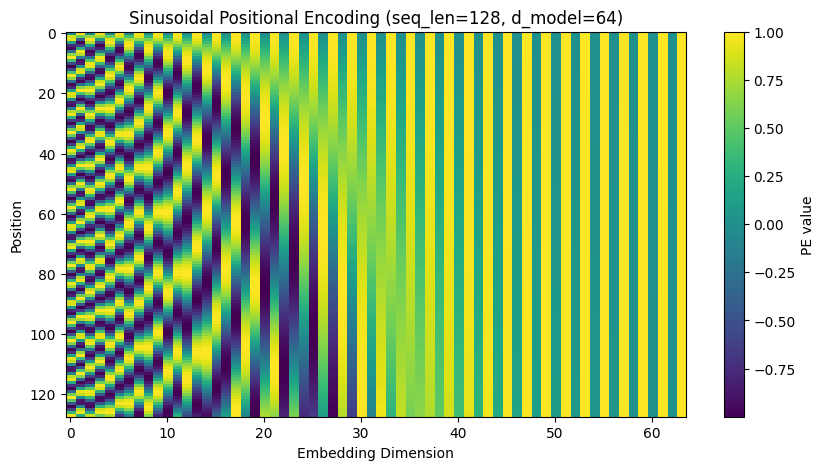

In [2]:
import numpy as np

import matplotlib.pyplot as plt

# 若 Notebook 其他 cell 已有設定，優先沿用
seq_len = globals().get("seq_len", 128)
d_model = globals().get("d_model", 64)

def sinusoidal_positional_encoding(seq_len, d_model):
    position = np.arange(seq_len)[:, np.newaxis]                         # (seq_len, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)  # 偶數維度
    pe[:, 1::2] = np.cos(position * div_term)  # 奇數維度
    return pe

pe = sinusoidal_positional_encoding(seq_len, d_model)

# 視覺化 1: Heatmap
plt.figure(figsize=(10, 5))
plt.imshow(pe, aspect="auto", cmap="viridis")
plt.colorbar(label="PE value")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title(f"Sinusoidal Positional Encoding (seq_len={seq_len}, d_model={d_model})")
plt.show()

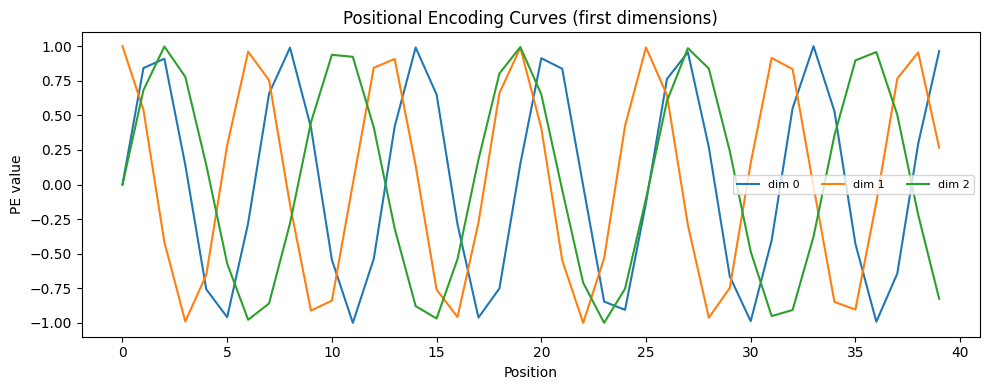

In [7]:
# 視覺化 2: 前幾個維度隨 position 的變化
plt.figure(figsize=(10, 4))
num_dims_to_plot = min(3, d_model)
for i in range(num_dims_to_plot):
    plt.plot(pe[:40, i], label=f"dim {i}")
plt.xlabel("Position")
plt.ylabel("PE value")
plt.title("Positional Encoding Curves (first dimensions)")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()